In [2]:
#Imports and data loading

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import torchvision.utils as vutils
from preprocessing import get_celeba_dataloaders

sns.set_theme(style="whitegrid")
%matplotlib inline

data_path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(f"Dataset location: {data_path}")

attr_df = pd.read_csv(os.path.join(data_path, "list_attr_celeba.csv"))
partition_df = pd.read_csv(os.path.join(data_path, "list_eval_partition.csv"))

attr_df = attr_df.replace(-1, 0)

/home/staff/brachwal/public/conda/miniconda3/envs/monai_hface_accelerate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset location: /home/stud2023/3lach/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


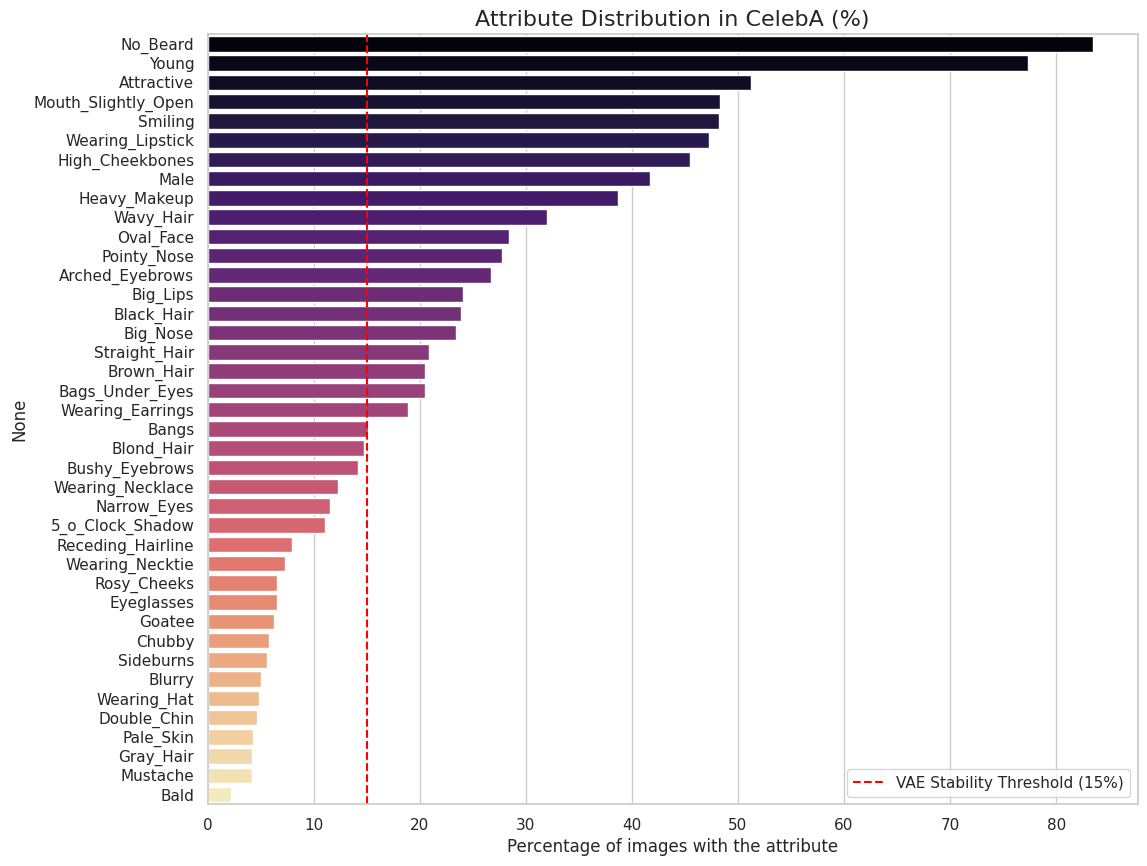

In [3]:
# Attribute distribution analysis

attr_counts = attr_df.drop('image_id', axis=1).mean() * 100
attr_counts = attr_counts.sort_values(ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x=attr_counts.values, y=attr_counts.index, hue=attr_counts.index, palette="magma", legend=False)
plt.title("Attribute Distribution in CelebA (%)", fontsize=16)
plt.xlabel("Percentage of images with the attribute", fontsize=12)
plt.axvline(x=15, color='red', linestyle='--', label='VAE Stability Threshold (15%)')
plt.legend()
plt.show()

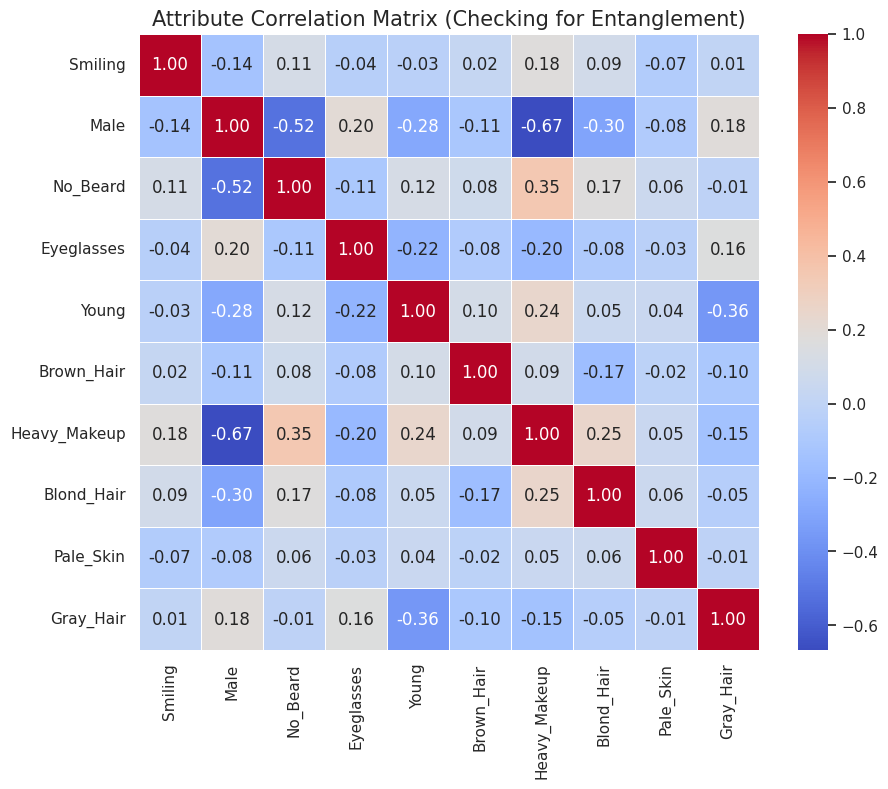

In [4]:
# Feature correlation analysis

target_features = ['Smiling', 'Male', 'No_Beard', 'Eyeglasses', 'Young', 
                   'Brown_Hair', 'Heavy_Makeup', 'Blond_Hair', 'Pale_Skin', 'Gray_Hair']

correlation_matrix = attr_df[target_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Attribute Correlation Matrix (Checking for Entanglement)", fontsize=15)
plt.show()

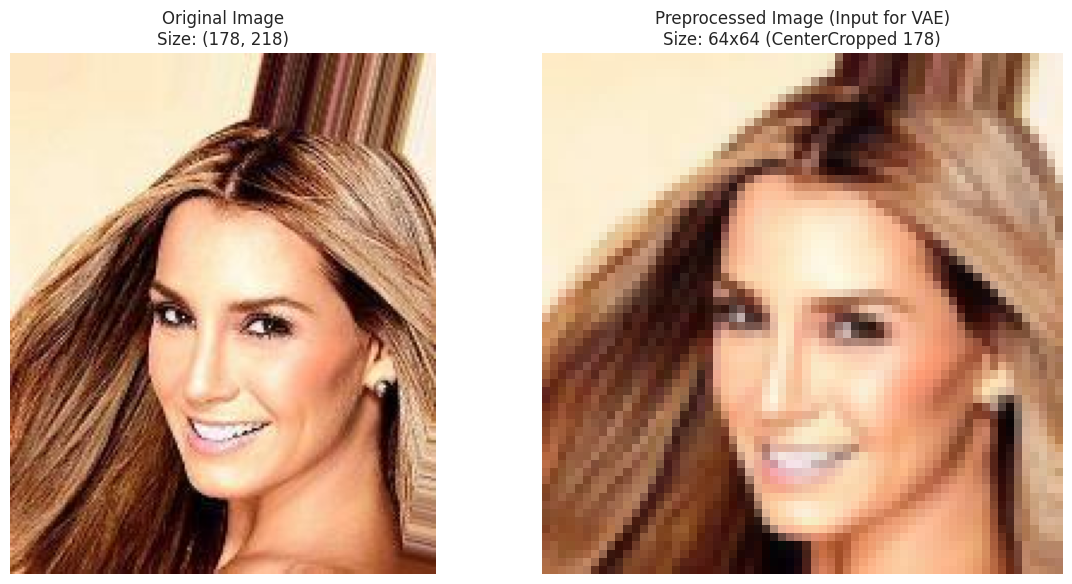

In [5]:
# Original vs Preprocessed - comparison

from PIL import Image
from preprocessing import get_celeba_dataloaders, get_transforms

sample_img_name = attr_df.iloc[0]['image_id']
raw_img_path = os.path.join(data_path, "img_align_celeba", "img_align_celeba", sample_img_name)

raw_image = Image.open(raw_img_path)

preprocess = get_transforms(img_size=64)
preprocessed_image = preprocess(raw_image)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(raw_image)
axes[0].set_title(f"Original Image\nSize: {raw_image.size}", fontsize=12)
axes[0].axis('off')

axes[1].imshow(np.transpose(preprocessed_image.numpy(), (1, 2, 0)))
axes[1].set_title(f"Preprocessed Image (Input for VAE)\nSize: 64x64 (CenterCropped 178)", fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Preparing Indices for all Target Features
import json

target_features = [
    'Smiling', 'Male', 'No_Beard', 'Eyeglasses', 'Young', 
    'Brown_Hair', 'Heavy_Makeup', 'Blond_Hair', 'Pale_Skin', 'Gray_Hair'
]

def get_clean_indices(df, feature_name, n_samples=500):
    pos_indices = df[df[feature_name] == 1].head(n_samples).index.tolist()
    neg_indices = df[df[feature_name] == 0].head(n_samples).index.tolist()
    return pos_indices, neg_indices

latent_manipulation_map = {}

for feature in target_features:
    pos, neg = get_clean_indices(attr_df, feature)
    latent_manipulation_map[feature] = {
        'pos': pos,
        'neg': neg
    }
    print(f"Indices for '{feature}' collected (Pos: {len(pos)}, Neg: {len(neg)})")

with open('latent_manipulation_map.json', 'w') as f:
    json.dump(latent_manipulation_map, f, indent=4)

print("\nSuccess! Full latent manipulation map saved to 'latent_manipulation_map.json'")


Indices for 'Smiling' collected (Pos: 500, Neg: 500)
Indices for 'Male' collected (Pos: 500, Neg: 500)
Indices for 'No_Beard' collected (Pos: 500, Neg: 500)
Indices for 'Eyeglasses' collected (Pos: 500, Neg: 500)
Indices for 'Young' collected (Pos: 500, Neg: 500)
Indices for 'Brown_Hair' collected (Pos: 500, Neg: 500)
Indices for 'Heavy_Makeup' collected (Pos: 500, Neg: 500)
Indices for 'Blond_Hair' collected (Pos: 500, Neg: 500)
Indices for 'Pale_Skin' collected (Pos: 500, Neg: 500)
Indices for 'Gray_Hair' collected (Pos: 500, Neg: 500)

Success! Full latent manipulation map saved to 'latent_manipulation_map.json'


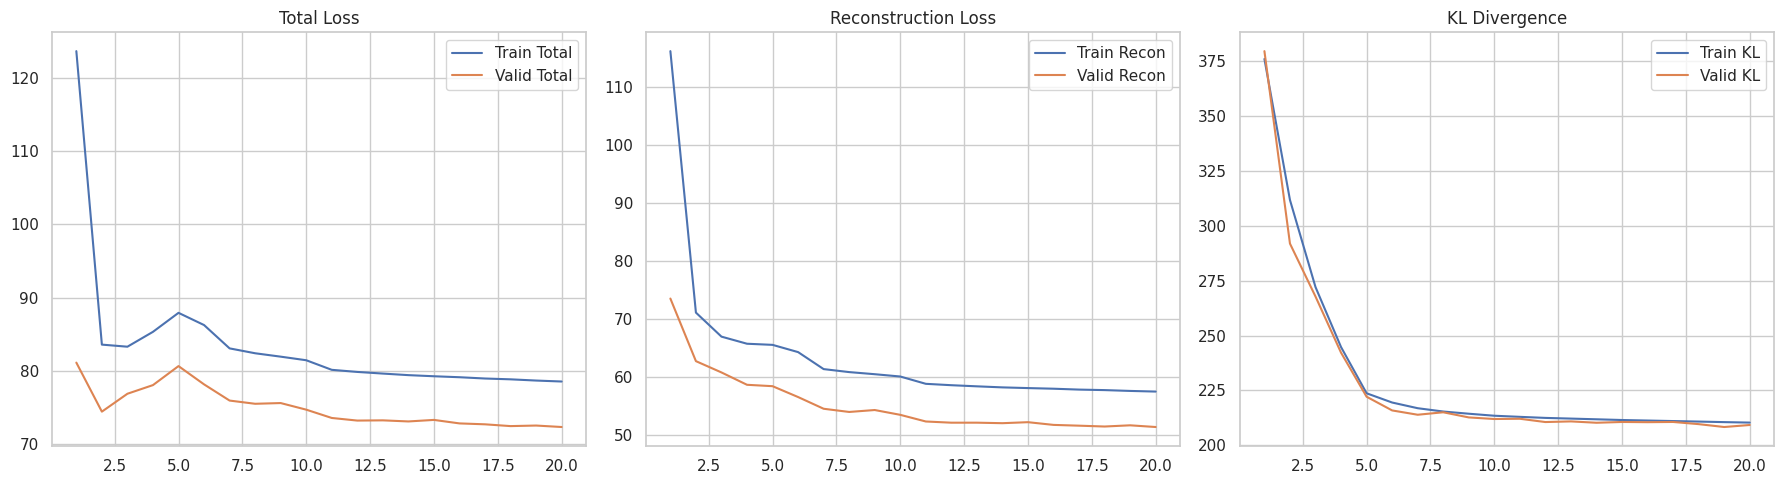

In [7]:
import json
import matplotlib.pyplot as plt

# Load training history
with open('checkpoints/training_history.json', 'r') as f:
    history = json.load(f)

# Extract metrics
train_total = [x['total'] for x in history['train']]
valid_total = [x['total'] for x in history['valid']]
train_kl = [x['kl'] for x in history['train']]
valid_kl = [x['kl'] for x in history['valid']]
train_recon = [x['recon'] for x in history['train']]
valid_recon = [x['recon'] for x in history['valid']]

epochs = range(1, len(train_total) + 1)

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, train_total, label='Train Total')
axes[0].plot(epochs, valid_total, label='Valid Total')
axes[0].set_title('Total Loss')
axes[0].legend()

axes[1].plot(epochs, train_recon, label='Train Recon')
axes[1].plot(epochs, valid_recon, label='Valid Recon')
axes[1].set_title('Reconstruction Loss')
axes[1].legend()

axes[2].plot(epochs, train_kl, label='Train KL')
axes[2].plot(epochs, valid_kl, label='Valid KL')
axes[2].set_title('KL Divergence')
axes[2].legend()

plt.tight_layout()
plt.show()

In [8]:
import torch
import numpy as np
from torchvision.utils import make_grid
from model import VAE
from preprocessing import get_celeba_dataloaders

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load dataloaders
_, valid_loader, _ = get_celeba_dataloaders(batch_size=8, img_size=64, num_workers=4, pin_memory=True)

# Initialize model and load weights
model = VAE(latent_dim=128, cond_dim=40).to(device)
checkpoint = torch.load('checkpoints/best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# Set to evaluation mode (disables dropout, fixes batchnorm, makes reparameterization deterministic)
model.eval()
print(f"Model loaded from epoch {checkpoint['epoch']} with valid loss {checkpoint['valid_loss']:.4f}")

Using device: cuda


Model loaded from epoch 20 with valid loss 72.3252


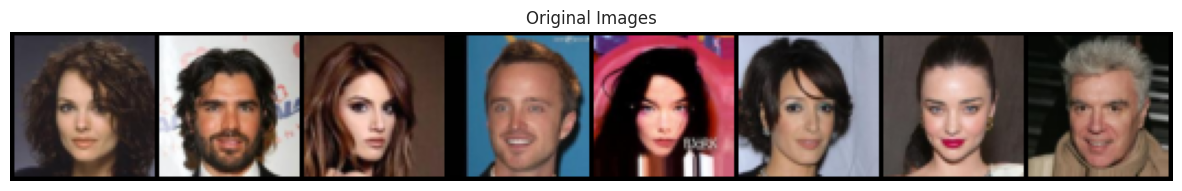

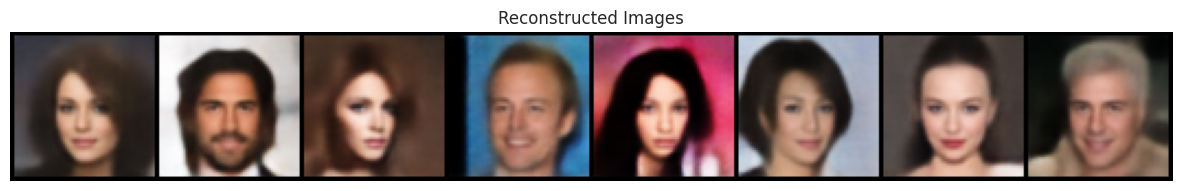

In [9]:
# Fetch one batch of validation images and labels
images, labels = next(iter(valid_loader))
images = images.to(device)
labels = labels.float().to(device)

# Forward pass without calculating gradients
with torch.no_grad():
    reconstructed, _, _ = model(images, labels)

# Helper function to display image grids
def show_tensor_images(image_tensor, title):
    grid = make_grid(image_tensor.cpu(), nrow=8, normalize=True)
    plt.figure(figsize=(15, 5))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(title)
    plt.axis('off')
    plt.show()

show_tensor_images(images, "Original Images")
show_tensor_images(reconstructed, "Reconstructed Images")

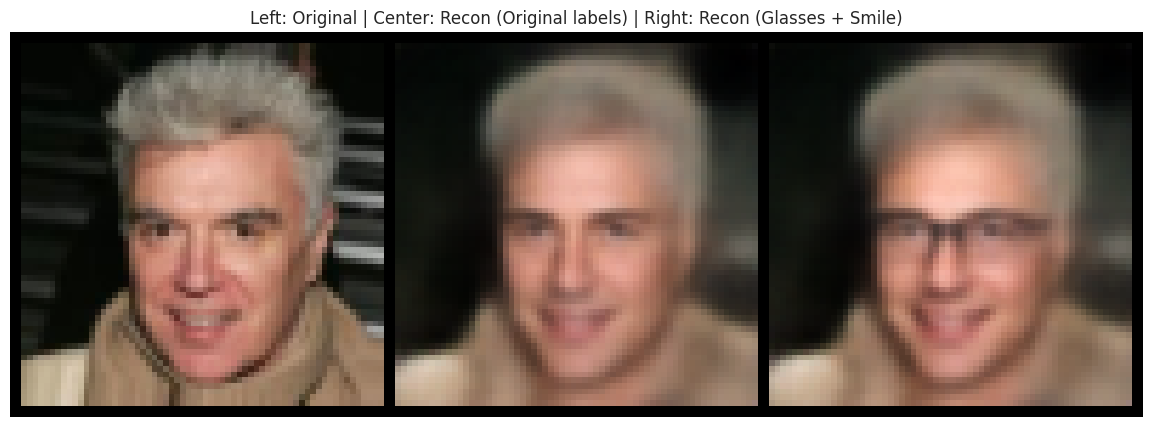

In [10]:
# CelebA attribute standard indexing
# Eyeglasses index: 15
# Smiling index: 31


# Select the image and its attributes from the batch
idx = 7
single_image = images[idx:idx+1]
original_label = labels[idx:idx+1].clone()

with torch.no_grad():
    # Step 1: Encode image to latent space
    mu, log_var = model.encode(single_image, original_label)
    z = mu # Use mean directly for deterministic generation during evaluation

    # Step 2: Decode with original attributes
    recon_original = model.decode(z, original_label)
    
    # Step 3: Modify the condition vector (force glasses to 1.0)
    # CLatent Atribute Scalling
    modified_label = original_label.clone()
    modified_label[0, 15] = 2.0 # Force glasses ON
    modified_label[0, 31] = 2.0 # Force smiling ON
    
    # Step 4: Decode with modified attributes
    recon_modified = model.decode(z, modified_label)

# Concatenate and display the results
comparison = torch.cat([single_image, recon_original, recon_modified], dim=0)
show_tensor_images(comparison, "Left: Original | Center: Recon (Original labels) | Right: Recon (Glasses + Smile)")

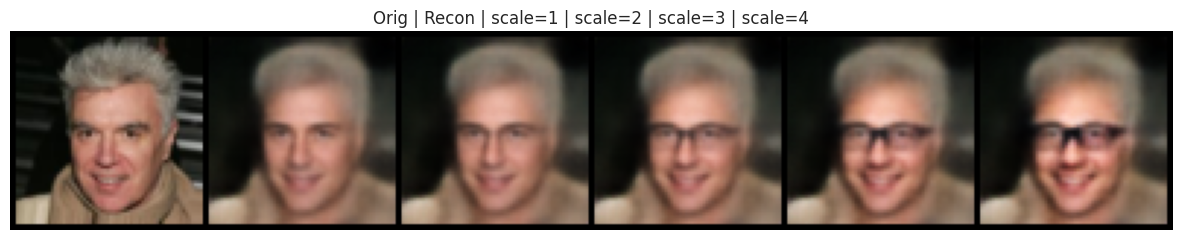

In [ ]:
# Select the image and its attributes from the batch
idx = 7
single_image = images[idx:idx+1]
original_label = labels[idx:idx+1].clone()

with torch.no_grad():
    mu, _ = model.encode(single_image, original_label)
    z = mu 
    recon_original = model.decode(z, original_label)
    
    # List to store the generated images
    results = [single_image, recon_original]
    
    # Evaluate smooth transition from scale 1.0 to 4.0
    scales = [1.0, 2.0, 3.0, 4.0]
    
    for scale in scales:
        modified_label = original_label.clone()
        modified_label[0, 15] = scale 
        modified_label[0, 31] = scale 
        
        recon_mod = model.decode(z, modified_label)
        results.append(recon_mod)


comparison = torch.cat(results, dim=0)
show_tensor_images(comparison, "Orig | Recon | scale=1 | scale=2 | scale=3 | scale=4")

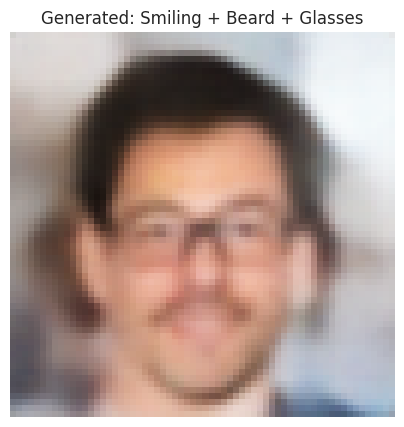

In [12]:
# 1. Create a blank attribute vector
my_custom_attr = torch.zeros((1, 40)).to(device)

# 2. Set specific visual features
my_custom_attr[0, 31] = 1.0  # Smiling: Yes
my_custom_attr[0, 15] = 2.0  # Eyeglasses: Yes
my_custom_attr[0, 24] = -2.0  # No_Beard: No (which means Beard: Yes)
my_custom_attr[0, 20] = 1.0  # Male: Yes (helps the model generate a realistic beard)

# 3. Sample random point from latent space
z = torch.randn(1, 128).to(device)

# 4. Generate the image
model.eval()
with torch.no_grad():
    generated_face = model.decode(z, my_custom_attr)


# 5. Plot the result
plt.figure(figsize=(5, 5))
plt.imshow(generated_face[0].cpu().permute(1, 2, 0).numpy())
plt.title("Generated: Smiling + Beard + Glasses")
plt.axis('off')
plt.show()

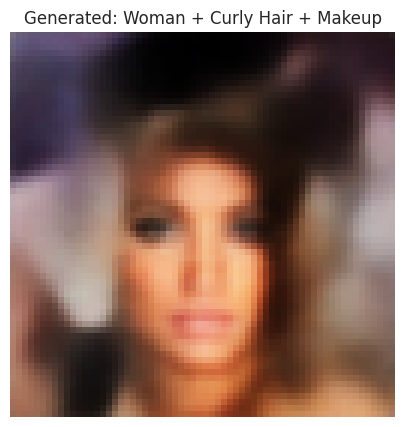

In [13]:
# 1. Create a blank attribute vector
woman_custom_attr = torch.zeros((1, 40)).to(device)

# 2. Set specific visual features
woman_custom_attr[0, 9] = 3.0   # Curly Hair: Yes
woman_custom_attr[0, 18] = 3.0  # Heavy Makeup: Yes
woman_custom_attr[0, 36] = 3.0  # Wearing Lipstick: Yes
woman_custom_attr[0, 20] = 0.0  # Male: No (Female)
woman_custom_attr[0, 39] = 1.0  # Young: Yes (optional, helps with skin clarity)

# 3. Sample random point from latent space
z = torch.randn(1, 128).to(device)

# 4. Generate the image
model.eval()
with torch.no_grad():
    generated_woman = model.decode(z, woman_custom_attr)

# 5. Plot the result
plt.figure(figsize=(5, 5))
plt.imshow(generated_woman[0].cpu().permute(1, 2, 0).numpy())
plt.title("Generated: Woman + Curly Hair + Makeup")
plt.axis('off')
plt.show()

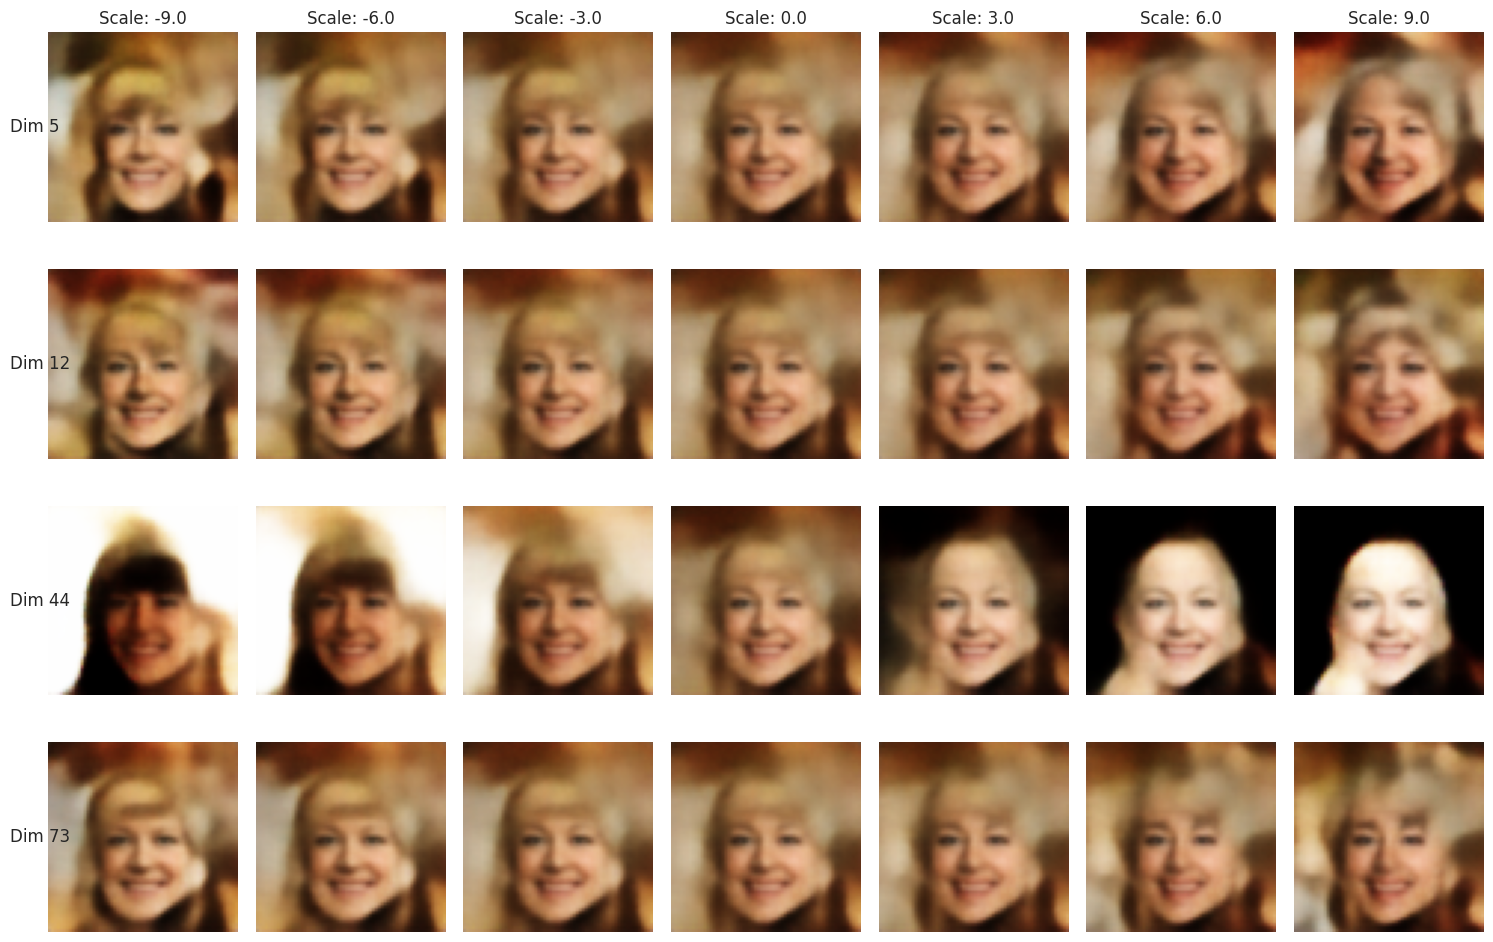

In [20]:
import torch
import matplotlib.pyplot as plt

# Define the dimensions to traverse and the scale values
dims_to_traverse = [5, 12, 44, 73] 
scales = torch.linspace(-9.0, 9.0, steps=7)

# Generate base latent vector and select base condition vector
base_z = torch.randn(1, 128).to(device)
base_c = labels[0].unsqueeze(0).to(device)

# Initialize plot
fig, axes = plt.subplots(len(dims_to_traverse), len(scales), figsize=(15, 2.5 * len(dims_to_traverse)))

model.eval()
with torch.no_grad():
    for row_idx, dim_idx in enumerate(dims_to_traverse):
        for col_idx, scale_val in enumerate(scales):
           
            z_mod = base_z.clone()
            z_mod[0, dim_idx] = scale_val
            
            gen_img = model.decode(z_mod, base_c)
            
            # Format image for matplotlib (C, H, W) -> (H, W, C)
            img_np = gen_img.squeeze(0).cpu().permute(1, 2, 0).numpy()
            
            # Handle axes indexing depending on the number of dimensions
            ax = axes[row_idx, col_idx] if len(dims_to_traverse) > 1 else axes[col_idx]
            
            ax.imshow(img_np)
            ax.axis('off')
            
            # Add column titles for the first row
            if row_idx == 0:
                ax.set_title(f"Scale: {scale_val:.1f}")
            
            # Add row labels for the first column
            if col_idx == 0:
                ax.text(-0.2, 0.5, f"Dim {dim_idx}", transform=ax.transAxes, fontsize=12, va='center')

plt.tight_layout()
plt.show()